<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install pyspark

In [28]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
# Initialize Spark with optimizations for large data
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
file_path = '/content/drive/MyDrive/CSV/Trade_CropsLivestock_E_All_Data_(Normalized).csv'

df = spark.read.csv(file_path, header=True, inferSchema=True)

In [37]:
df_before = df  # This is just a reference, not a copy

In [24]:
# Cache the dataframe to avoid recomputation
df.cache()

total_records = df.count()
print(f"Total records: {total_records:,}")
print(f"Total columns: {len(df.columns)}")

Total records: 17,270,631
Total columns: 14


In [33]:
print("\n--- Dataset Overview (BEFORE) ---")
# Check rows with missing values BEFORE
print("\n--- Rows with Missing Values (BEFORE) ---")

# Count rows that have ANY missing value
rows_with_missing = df.filter(
    F.greatest(*[F.when(F.col(c).isNull(), 1).otherwise(0) for c in df.columns]) == 1
).count()

rows_complete = total_records - rows_with_missing
print(f"  Complete rows (no missing): {rows_complete:,} ({rows_complete/total_records*100:.2f}%)")
print(f"  Rows with missing values: {rows_with_missing:,} ({rows_with_missing/total_records*100:.2f}%)")


--- Dataset Overview (BEFORE) ---

--- Rows with Missing Values (BEFORE) ---
  Complete rows (no missing): 952,262 (5.51%)
  Rows with missing values: 16,318,369 (94.49%)


In [30]:
# Get year range
min_year = df.select(F.min('Year')).collect()[0][0]
max_year = df.select(F.max('Year')).collect()[0][0]
print(f"Year range: {min_year} - {max_year}")

Year range: 1961 - 2024


In [31]:
# Check missing values BEFORE
print("\n--- Missing Values Count (BEFORE) ---")
missing_before = []
for col in df.columns:
    missing_count = df.filter(F.col(col).isNull()).count()
    missing_percent = (missing_count / total_records) * 100
    if missing_count > 0:
        print(f"  {col}: {missing_count:,} ({missing_percent:.2f}%)")
        missing_before.append((col, missing_count, missing_percent))


--- Missing Values Count (BEFORE) ---
  Note: 16,318,369 (94.49%)


In [32]:
# Check duplicates BEFORE
print("\n--- Duplicate Records (BEFORE) ---")
duplicates_before = total_records - df.distinct().count()
print(f"Duplicate rows: {duplicates_before:,}")


--- Duplicate Records (BEFORE) ---
Duplicate rows: 0



EDA 1: COUNT FOR EACH TRADE ITEM (BEFORE)

📊 TOTAL DISTINCT FOOD ITEMS: 616
📊 TOTAL RECORDS: 17,270,631

Top 10 items by record count:
+-------------------------+------------+---------------------+
|Item                     |Record_Count|Total_Value          |
+-------------------------+------------+---------------------+
|Other food               |105119      |1.8241051753618002E11|
|Other food nes           |59943       |6.840709759404994E10 |
|Fruit                    |59839       |7.521711154646002E10 |
|Vegetables               |59581       |4.372864335262999E10 |
|Cereal preparations total|59055       |3.995791022071002E10 |
|Vegetable Oil and Fat    |58592       |5.476229281695002E10 |
|Fodder and Feeding Stuff |58188       |8.380826597335E10    |
|Alcoholic Beverages      |58126       |3.727111354515001E10 |
|Tobacco                  |57952       |1.7513925434230003E10|
|Dairy Products           |57678       |3.642985770055E10    |
+-------------------------+------------+-----

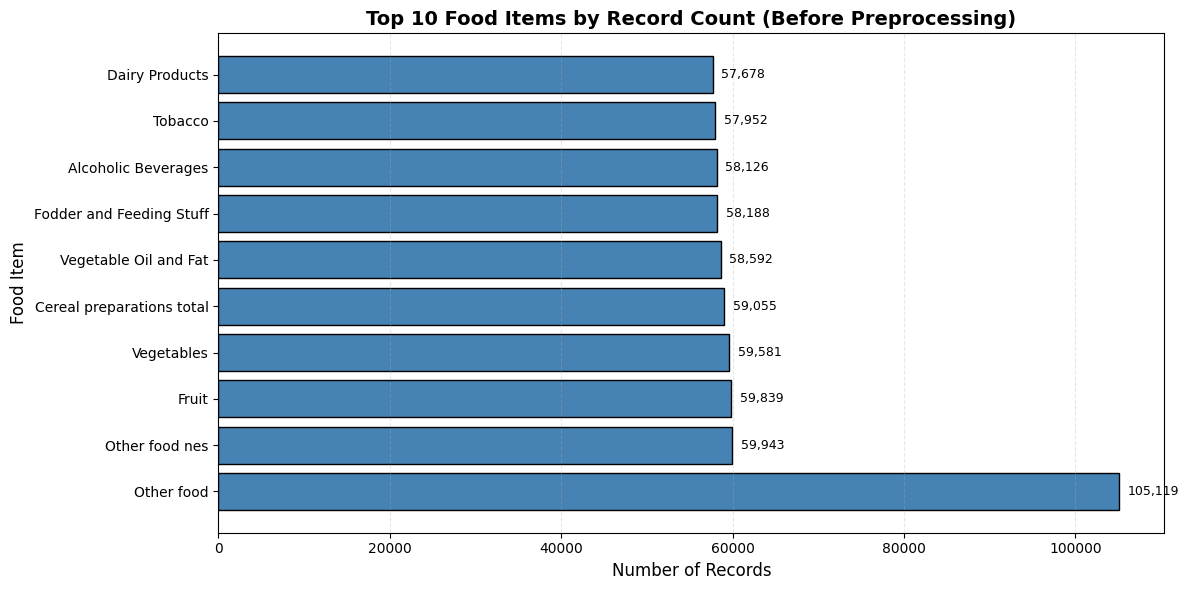

In [43]:
# EDA 1: COUNT FOR EACH TRADE ITEM (BEFORE)
print("\n" + "=" * 60)
print("EDA 1: COUNT FOR EACH TRADE ITEM (BEFORE)")
print("=" * 60)

# Show total distinct food items
distinct_items = df_before.select("Item").distinct().count()
print(f"\n📊 TOTAL DISTINCT FOOD ITEMS: {distinct_items:,}")
print(f"📊 TOTAL RECORDS: {df_before.count():,}")

# Count for each trade item
item_counts_before = df_before.groupBy("Item").agg(
    F.count("*").alias("Record_Count"),
    F.sum("Value").alias("Total_Value")
).orderBy(F.desc("Record_Count"))

print("\nTop 10 items by record count:")
item_counts_before.show(10, truncate=False)

# Collect for visualization (top 10 only)
item_before_list = item_counts_before.limit(10).collect()
items_before = [row.Item for row in item_before_list]
counts_before = [row.Record_Count for row in item_before_list]

# VISUALIZATION for EDA 1 (BEFORE)
plt.figure(figsize=(12, 6))

# Bar chart - horizontal for better category label readability
plt.barh(items_before, counts_before, color='steelblue', edgecolor='black')

# Clear, descriptive title
plt.title('Top 10 Food Items by Record Count (Before Preprocessing)',
          fontsize=14, fontweight='bold')

# Label axes clearly
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Food Item', fontsize=12)

# Add value labels for readability
for i, v in enumerate(counts_before):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

# Add grid for readability (but only on x-axis)
plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()